In [1]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb.model import GRSC_CB_Model
from grsc_cb.instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

In [2]:
# number of land parcels
n = 100
# number of species
m = 14
# number of max connected areas
k = 3
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 2
# tau threshold
tau = 0.8

External nodes: [33, 42, 11, 76, 47, 16, 81, 82, 88, 89, 26, 61]


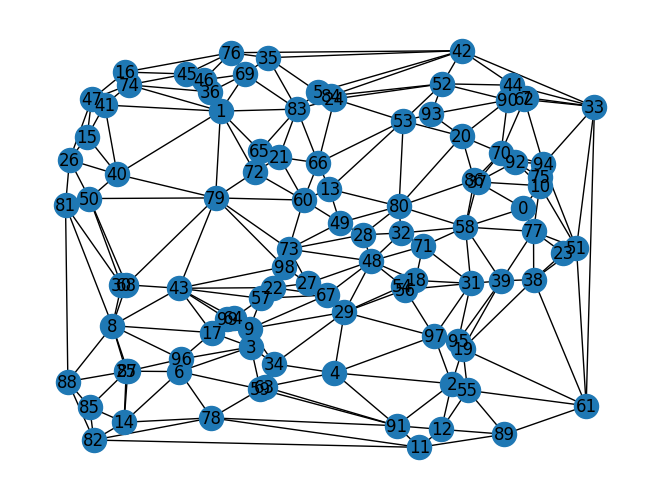

In [3]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, h = simplex
    G.add_edge(i, j)
    G.add_edge(j, h)
    G.add_edge(i, h)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {[int(i) for i in external_nodes]}")

In [4]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [5]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2) // 2

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

In [6]:
# toy instance
V, E = set(G.nodes), set(G.edges)
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, tau, d)

instance.draw_graph()

GRSC_CB_Instance(|V|=100, |E|=285, |S1|=4, |S2|=10, P1=4, P2=5, k=3, d=2)
Set parameter Username
Set parameter LicenseID to value 2796100
Academic license - for non-commercial use only - expires 2027-03-23
Set parameter LazyConstraints to value 1
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 28, 'corecon-frc': 0, 'cover-s1': 24, 'cover-s2': 0, 'scc': 1}
Status: 2 Optimal
Objective: 1094.0
Nodes in the reserve (x): [3, 6, 8, 9, 11, 14, 17, 25, 30, 34, 43, 59, 63, 68, 78, 81, 82, 85, 87, 88, 91, 96]
Nodes in the core (z): [6, 14, 25, 85, 87]
Species protected (u): [0, 1, 2, 3, 5, 7, 8, 9, 13]
r-arc-node separators (y): [14]


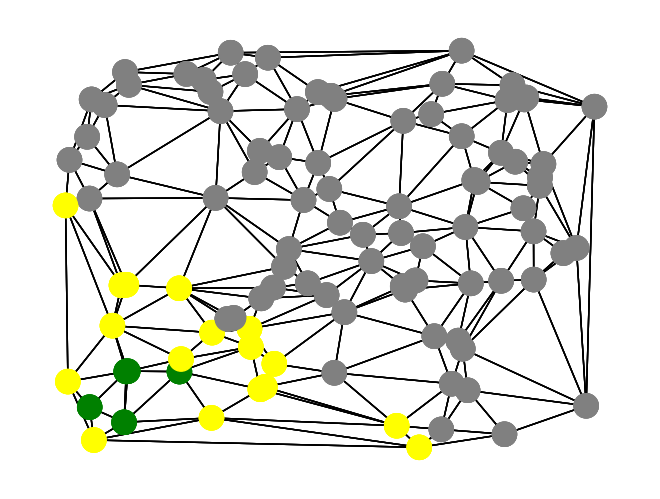

In [7]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=100, |E|=285, |S1|=4, |S2|=10, P1=4, P2=5, k=3, d=2)
Set parameter LazyConstraints to value 1
	 * Starting construction heuristic...
	 * Initial solution found with Construction Heuristic. Nodes: {0, 7, 10, 20, 23, 24, 31, 32, 33, 37, 38, 39, 42, 44, 51, 52, 53, 58, 61, 62, 70, 71, 75, 77, 80, 84, 86, 90, 92, 93, 94}
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 25, 'corecon-frc': 0, 'cover-s1': 37, 'cover-s2': 0, 'scc': 2}
Status: 2 Optimal
Objective: 1094.0
Nodes in the reserve (x): [3, 6, 8, 9, 11, 14, 17, 25, 30, 34, 43, 59, 63, 68, 78, 81, 82, 85, 87, 88, 91, 96]
Nodes in the core (z): [6, 14, 25, 85, 87]
Species protected (u): [0, 1, 2, 3, 4, 6, 10, 12, 13]
r-arc-node separators (y): [6, 14]


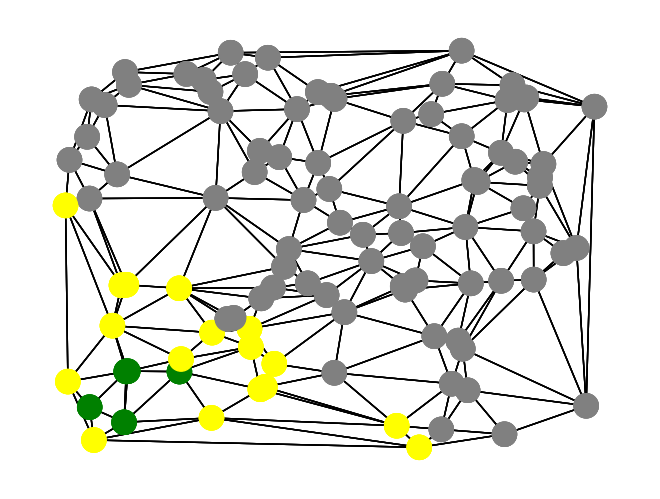

In [8]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=100, |E|=285, |S1|=4, |S2|=10, P1=4, P2=5, k=3, d=2)
Set parameter LazyConstraints to value 1
	 * Starting construction heuristic...
	 * Initial solution found with Construction Heuristic. Nodes: {0, 2, 4, 7, 10, 11, 12, 19, 23, 29, 31, 32, 33, 37, 38, 39, 42, 44, 51, 55, 56, 58, 59, 61, 62, 63, 70, 71, 75, 77, 78, 80, 82, 86, 89, 91, 92, 94, 95, 97}
	 * Starting local branching heuristic...
	 * Added constraints: {'corecon-int': 44, 'corecon-frc': 0, 'cover-s1': 10, 'cover-s2': 0, 'scc': 1}
	 * Added constraints: {'corecon-int': 0, 'corecon-frc': 0, 'cover-s1': 8, 'cover-s2': 0, 'scc': 3}
	 * Added constraints: {'corecon-int': 0, 'corecon-frc': 0, 'cover-s1': 8, 'cover-s2': 0, 'scc': 3}
	 * Added constraints: {'corecon-int': 0, 'corecon-frc': 0, 'cover-s1': 8, 'cover-s2': 0, 'scc': 3}
	 * LB heuristic completed. Best objective: 1884.00, Iterations: 4
	 * Starting gurobi optimization...
	 * Added constraints: {'corecon-int': 0, 'corecon-frc': 0, 'cover-s1': 8, 'cov

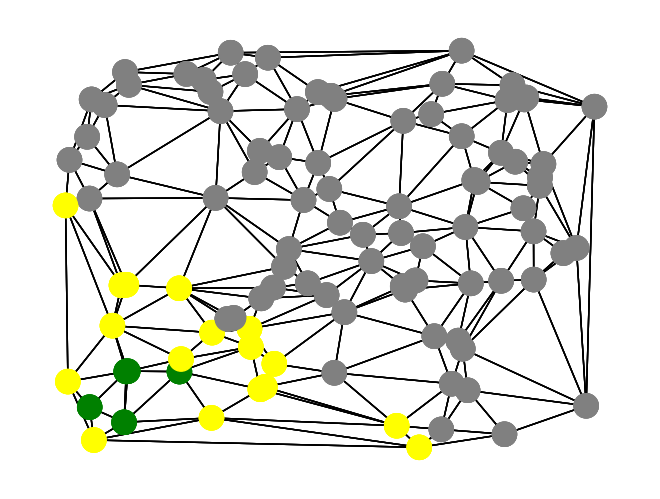

In [9]:
print(instance)
model = GRSC_CB_Model(instance)
result = model.solve(cp_heuristic=True, lb_heuristic=True)
model.print_solution()
model.print_graph()